#  **Fase 1: Inspeksi dan Eksplorasi Data Awal (Data Loading & Profiling)**

In [2]:
import pandas as pd
from google.colab import files

In [3]:
print("Silakan upload file 'work_from_home_burnout_dataset (1).csv':")
uploaded = files.upload()

Silakan upload file 'work_from_home_burnout_dataset (1).csv':


Saving work_from_home_burnout_dataset (1).csv to work_from_home_burnout_dataset (1).csv


In [4]:
df = pd.read_csv("work_from_home_burnout_dataset (1).csv")

In [11]:

display(df.head())

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk
0,1,Weekday,9.59,11.86,4,2,0,7.55,91.2,19.17,Low
1,1,Weekend,7.38,10.33,4,1,0,6.69,82.0,29.70,Low
2,1,Weekend,6.31,8.92,1,2,0,8.87,80.6,32.93,Low
3,1,Weekday,8.34,10.70,4,1,1,8.13,70.0,45.47,Low
4,1,Weekend,6.97,9.83,1,2,0,5.85,67.1,51.61,Low


In [12]:
print("\n--- Informasi Tipe Data dan Missing Values ---")
df.info()


--- Informasi Tipe Data dan Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1800 non-null   int64  
 1   day_type              1800 non-null   object 
 2   work_hours            1800 non-null   float64
 3   screen_time_hours     1800 non-null   float64
 4   meetings_count        1800 non-null   int64  
 5   breaks_taken          1800 non-null   int64  
 6   after_hours_work      1800 non-null   int64  
 7   sleep_hours           1800 non-null   float64
 8   task_completion_rate  1800 non-null   float64
 9   burnout_score         1800 non-null   float64
 10  burnout_risk          1800 non-null   object 
dtypes: float64(5), int64(4), object(2)
memory usage: 154.8+ KB


In [9]:
print("\n--- Ringkasan Statistik Data ---")
display(df.describe())


--- Ringkasan Statistik Data ---


,user_id,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,90.500000,6.515117,9.271406,1.941111,3.028889,0.358889,6.996467,72.308556,44.009978
std,51.975162,2.290521,2.409253,1.696178,1.417844,0.479808,1.061740,14.978647,23.881782
min,1.000000,3.000000,4.510000,0.000000,1.000000,0.000000,4.500000,40.000000,2.500000
25%,45.750000,4.430000,7.240000,1.000000,2.000000,0.000000,6.280000,62.300000,25.370000
50%,90.500000,6.445000,9.210000,2.000000,3.000000,0.000000,6.990000,74.500000,39.270000
75%,135.250000,8.510000,11.310000,3.000000,4.000000,1.000000,7.750000,83.700000,58.197500
max,180.000000,12.170000,15.700000,10.000000,5.000000,1.000000,10.800000,107.200000,143.920000


# **Fase 2: Pra-Pemrosesan dan Penyiapan Matriks (Data Preprocessing & Scaling)**

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [14]:
# 1. Membuang kolom yang dapat merusak model
df_cleaned = df.drop(columns=['user_id', 'burnout_risk'])

In [15]:
# 2. Mengubah teks kategori menjadi angka biner (Encoding)
#'Weekday' menjadi 0, dan 'Weekend' menjadi 1
df_cleaned['day_type'] = df_cleaned['day_type'].map({'Weekday': 0, 'Weekend': 1})

In [17]:
# 3. Memisahkan Matriks Fitur (X) dan Vektor Target (y)
X = df_cleaned.drop(columns=['burnout_score'])
y = df_cleaned['burnout_score']

In [18]:
# 4. Memecah data menjadi Data Latih (80%) dan Data Uji (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# 5. Menyeragamkan Skala Numerik (Standardisasi)
scaler = StandardScaler()

In [20]:
# fit_transform hanya untuk data latih (X_train)
X_train_scaled = scaler.fit_transform(X_train)

# transform saja untuk data uji (X_test) agar tidak terjadi data leakage
X_test_scaled = scaler.transform(X_test)

In [22]:
print("Preprocessing Selesai!")
print(f"Jumlah baris Data Latih: {X_train_scaled.shape[0]}")
print(f"Jumlah baris Data Uji: {X_test_scaled.shape[0]}")
print("\nUrutan Fitur yang siap masuk ke model:")
print(list(X.columns))

Preprocessing Selesai!
Jumlah baris Data Latih: 1440
Jumlah baris Data Uji: 360

Urutan Fitur yang siap masuk ke model:
['day_type', 'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'sleep_hours', 'task_completion_rate']


# **Fase 3: Eksperimen dan Evaluasi Algoritma (Model Training & Benchmarking)**

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor  # Tambahan Import CatBoost
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


In [29]:
# 1. Inisialisasi Keempat Algoritma
# Random_state dipasang agar hasil pemodelan konsisten
model_lr = LinearRegression()
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
# verbose=0 agar layar tidak penuh dengan teks proses loading CatBoost
model_cat = CatBoostRegressor(iterations=100, learning_rate=0.1, random_state=42, verbose=0)
# Dictionary untuk menyimpan model agar otomatis dilooping
models = {
    "Linear Regression": model_lr,
    "Random Forest": model_rf,
    "XGBoost": model_xgb,
    "CatBoost": model_cat  # CatBoost ditambahkan ke dalam daftar
}

In [30]:
# 2. Proses Pelatihan (Fitting) dan Prediksi
results = []

for name, model in models.items():
    # Model belajar dari data latih
    model.fit(X_train_scaled, y_train)

    # Model melakukan tebakan pada data uji
    y_pred = model.predict(X_test_scaled)

    # 3. Evaluasi Matematis
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Simpan hasil ke dalam list
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R-Squared": r2
    })

In [31]:
# 4. Menampilkan Hasil Komparasi dalam bentuk Tabel
df_results = pd.DataFrame(results)
print("--- HASIL EVALUASI 4 MODEL ---")
display(df_results.sort_values(by="RMSE", ascending=True).reset_index(drop=True))

--- HASIL EVALUASI 4 MODEL ---


,Model,MAE,RMSE,R-Squared
0,CatBoost,4.613862,5.813847,0.940084
1,Random Forest,4.818236,6.109733,0.933830
2,Linear Regression,4.800197,6.134106,0.933301
3,XGBoost,4.858370,6.235618,0.931076


**Kesimpulan:**
Berdasarkan hasil perbandingan di atas, kelompok kami memilih **CatBoost** sebagai model terbaik untuk di-deploy ke Streamlit. Alasannya, CatBoost punya nilai error terendah (RMSE = 5.81 dan MAE = 4.61) dengan R-Squared 0.94. Secara statistik, tebakan model ini adalah yang paling mendekati skor burnout aslinya.

# **Interpretasi Faktor Pemicu (Explainable AI dengan SHAP)**

--- FAKTOR UTAMA PEMICU BURNOUT ---


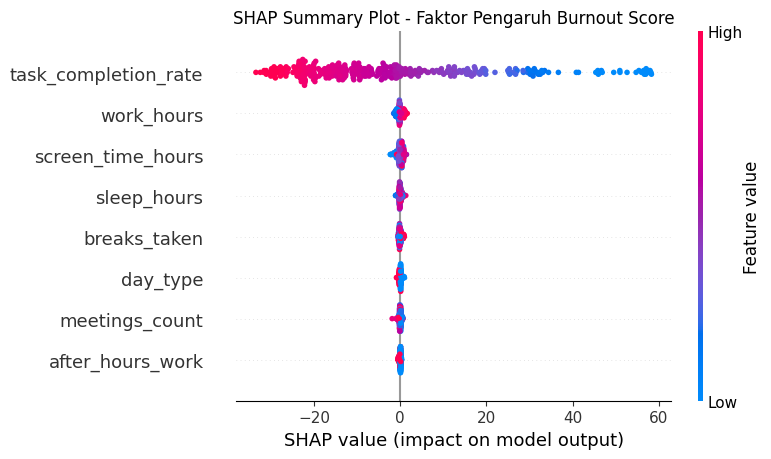

In [32]:
import shap
import matplotlib.pyplot as plt

# 1. Inisialisasi SHAP Explainer khusus untuk model pemenang kita (CatBoost)
explainer = shap.Explainer(model_cat)

# 2. Menghitung nilai SHAP (kontribusi masing-masing fitur) dari data uji
shap_values = explainer(X_test_scaled)

# 3. Menyiapkan nama fitur agar grafiknya mudah dibaca
feature_names = X.columns.tolist()

# 4. Memunculkan Grafik (Summary Plot)
print("--- FAKTOR UTAMA PEMICU BURNOUT ---")
plt.title("SHAP Summary Plot - Faktor Pengaruh Burnout Score")
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names)

## 📊 Interpretasi Hasil SHAP (Faktor Pemicu Burnout)

Dari grafik SHAP Summary Plot di atas, kita bisa melihat cara model CatBoost ngambil keputusan. Berikut adalah poin-poin penting penyebab tingginya skor burnout user:

1. **Fitur Paling Berpengaruh (Feature Importance)**
Fitur diurutkan dari atas ke bawah berdasarkan seberapa besar pengaruhnya. Bisa dilihat kalau `work_hours` (jam kerja) dan `screen_time_hours` (durasi menatap layar) ada di posisi teratas. Artinya, dua hal ini adalah penyumbang terbesar yang nentuin apakah skor burnout user bakal tinggi atau rendah. Semakin ke bawah, pengaruh fiturnya makin kecil.

2. **Arah Pengaruh (Warna dan Posisi Titik)**
* **Warna Titik:** Warna merah berarti nilainya tinggi (contoh: kerjanya terlalu lama atau kurang tidur ekstrim). Warna biru berarti nilainya rendah.
* **Posisi Kanan/Kiri (Sumbu X):** * Kalau titik merah ngumpul di **sebelah kanan** (garis 0 ke kanan), berarti kondisi tersebut **bikin skor burnout makin tinggi/parah**. Contohnya di fitur `work_hours`, titik merah memanjang ke kanan, yang secara statistik ngebuktiin kalau jam kerja berlebihan itu bahaya buat mental.
  * Sebaliknya, kalau titik merah ngumpul di **sebelah kiri**, berarti kondisi tersebut justru **nurunin skor burnout**. Contohnya di fitur `task_completion_rate`, titik merah ada di kiri. Ini jadi insight menarik: ternyata kalau persentase tugas yang diselesaikan tinggi (>80%), hal itu ngasih kepuasan tersendiri yang bisa meredam stres dan nekan skor burnout, meskipun jam kerjanya panjang.

# **Fase 5: Ekspor Artefak Pemodelan (Deployment Preparation)**

In [37]:
import joblib
from google.colab import files

# 1. Ekspor Model CatBoost terbaik
joblib.dump(model_cat, 'catboost_burnout_model.pkl')

# 2. Ekspor Scaler (Wajib untuk standardisasi input dari Streamlit)
joblib.dump(scaler, 'scaler_burnout.pkl')

print("Artefak berhasil dibuat!")

# 3. Mengunduh file dari server Colab ke lokal
files.download('catboost_burnout_model.pkl')
files.download('scaler_burnout.pkl')

Artefak berhasil dibuat!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Fase 6: Simulasi Prediksi Web (Sanity Check & Logic Validation)**

In [38]:
import joblib
import pandas as pd

# 1. Memuat kembali (Load) artefak yang sudah disimpan dari memori lokal
loaded_model = joblib.load('catboost_burnout_model.pkl')
loaded_scaler = joblib.load('scaler_burnout.pkl')

# 2. Membuat skenario data dummy (Simulasi input dari ketikan user di web Streamlit)
# Format urutan harus sama persis dengan kolom saat training!
data_user_baru = {
    'day_type': [0],                 # 0 = Weekday, 1 = Weekend
    'work_hours': [10.5],            # Bekerja 10.5 jam sehari
    'screen_time_hours': [13.0],     # Menatap layar 13 jam
    'meetings_count': [6],           # Ada 6 kali rapat
    'breaks_taken': [1],             # Hanya istirahat 1 kali
    'after_hours_work': [1],         # Ada lembur (1 = Ya, 0 = Tidak)
    'sleep_hours': [4.5],            # Hanya tidur 4.5 jam
    'task_completion_rate': [90.0]   # Tingkat penyelesaian tugas 90%
}

# Mengubah format ke DataFrame (bentuk matriks 2D)
df_input = pd.DataFrame(data_user_baru)

print("--- Data Input User dari Dashboard ---")
display(df_input)

# 3. Proses Scaling (Penyeragaman Skala)
input_scaled = loaded_scaler.transform(df_input)

# 4. Mengeksekusi Prediksi
prediksi_skor = loaded_model.predict(input_scaled)

print("\n--- Hasil Prediksi Sistem AI ---")
print(f"Skor Burnout Prediksi: {prediksi_skor[0]:.2f} / 100")

# 5. Simulasi Logika Keputusan
if prediksi_skor[0] < 40:
    print("Kategori Risiko: LOW (Aman, gaya hidup seimbang)")
elif prediksi_skor[0] < 70:
    print("Kategori Risiko: MEDIUM (Perlu intervensi, kurangi beban kerja/rapat)")
else:
    print("Kategori Risiko: HIGH (Bahaya, disarankan segera mengambil cuti dan istirahat total)")

--- Data Input User dari Dashboard ---


,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate
0,0,10.5,13.0,6,1,1,4.5,90.0



--- Hasil Prediksi Sistem AI ---
Skor Burnout Prediksi: 23.59 / 100
Kategori Risiko: LOW (Aman, gaya hidup seimbang)


### 📌 PESAN PENTING UNTUK INTEGRASI STREAMLIT

 model sama scaler-nya buat dipasang di dashboard:
1. `catboost_burnout_model.pkl` (Model utama CatBoost)
2. `scaler_burnout.pkl` (StandardScaler buat input data)

**⚠️ Catatan Krusial buat Coding di Streamlit:**
Pas  bikin DataFrame dari inputan user di UI (slider/inputan angka), **urutan kolomnya wajib disusun persis kaya daftar di bawah ini sebelum dimasukin ke scaler dan model**. Kalau urutannya ketukar, hasil prediksinya bakal berantakan atau bahkan error karena model ngebaca urutan angkanya secara matematis:

```python
# Urutan fitur wajib di Streamlit:
fitur_input = [
    'day_type',
    'work_hours',
    'screen_time_hours',
    'meetings_count',
    'breaks_taken',
    'after_hours_work',
    'sleep_hours',
    'task_completion_rate'
]